## Import Libraries and Data

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
sns.set()

In [3]:
insurance_df = pd.read_csv("insurance.csv")

In [4]:
insurance_df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


## EDA: Exploratory Data Analysis

In [5]:
## See if there are any missing values
insurance_df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [6]:
## Check data types for each column
insurance_df.isnull().info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   age       1338 non-null   bool 
 1   sex       1338 non-null   bool 
 2   bmi       1338 non-null   bool 
 3   children  1338 non-null   bool 
 4   smoker    1338 non-null   bool 
 5   region    1338 non-null   bool 
 6   charges   1338 non-null   bool 
dtypes: bool(7)
memory usage: 9.3 KB


In [7]:
## How does charges vary across region?
region = insurance_df.groupby(by='region')['charges'].mean()
region

region
northeast    13406.384516
northwest    12417.575374
southeast    14735.411438
southwest    12346.937377
Name: charges, dtype: float64

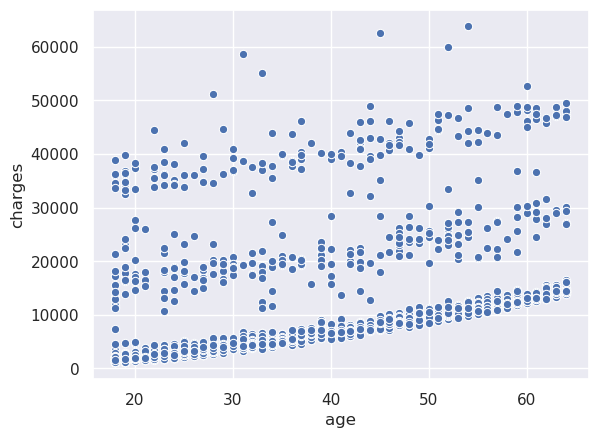

In [8]:
## How does charges vary across age?
## Visualized with a scatter plot
sns.scatterplot(data=insurance_df, x="age", y="charges")
plt.show()

## Model Preprocessing

#### Convert Categorical to numeric (binary) and encode

In [9]:
insurance_df['sex'] = insurance_df['sex'].apply(lambda x: 0 if x == 'female' else 1)
insurance_df['smoker'] = insurance_df['smoker'].apply(lambda x: 0 if x == 'no' else 1)
region_dummies = pd.get_dummies(insurance_df['region'],drop_first = True)
insurance_df = pd.concat([insurance_df, region_dummies],axis = 1)
insurance_df.drop(['region'], axis = 1, inplace = True)
insurance_df.head()

,age,sex,bmi,children,smoker,charges,northwest,southeast,southwest
0,19,0,27.900,0,1,16884.92400,0,0,1
1,18,1,33.770,1,0,1725.55230,0,1,0
2,28,1,33.000,3,0,4449.46200,0,1,0
3,33,1,22.705,0,0,21984.47061,1,0,0
4,32,1,28.880,0,0,3866.85520,1,0,0


#### Split into Features and Target

In [10]:
X = insurance_df.drop(columns = ['charges'])
y = insurance_df['charges']

In [11]:
X = np.array(X).astype('float32')
y = np.array(y).astype('float32')
y = y.reshape(-1,1)

#### Standardize Data

In [12]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler

scaler_x = StandardScaler()
X = scaler_x.fit_transform(X)

scaler_y = StandardScaler()
y = scaler_y.fit_transform(y)

#### Split into Training and Test

In [13]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size = 0.2)

## Building a Model in Sklearn

In [14]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from math import sqrt

lin_reg = LinearRegression()
lin_reg = lin_reg.fit(X_train,y_train)

#### Evaluating the Model

In [15]:
y_predict = lin_reg.predict(X_test)

y_predict_unscaled = scaler_y.inverse_transform(y_predict)
y_test_unscaled = scaler_y.inverse_transform(y_test)

In [17]:
RMSE = float(format(np.sqrt(mean_squared_error(y_test_unscaled,y_predict_unscaled)),'.3f'))
MSE = mean_squared_error(y_test_unscaled, y_predict_unscaled)

k = X_test.shape[1]
n = len(X_test)

MAE = mean_absolute_error(y_test_unscaled,y_predict_unscaled)
r2 = r2_score(y_test_unscaled,y_predict_unscaled)
adj_r2 = 1-(1-r2) * (n-1)/(n-k-1)

In [18]:
print('RMSE =',RMSE,'\nMSE = ',MSE, '\nMAE =',MAE,'\nR2',r2,'\nAdjusted R2 =',adj_r2)

RMSE = 6418.161 
MSE =  41192784.0 
MAE = 4325.9453 
R2 0.7509163964443142 
Adjusted R2 = 0.7432226944039841


## Train a Linear Learner using Sagemaker

In [19]:
import sagemaker
import boto3

sagemaker_session = sagemaker.Session()

bucket = 'sagemaker-medical-insurance-project'
prefix = 'linear_learner'

role = sagemaker.get_execution_role()
print(role)

arn:aws:iam::809503251832:role/service-role/AmazonSageMaker-ExecutionRole-20221018T215425


In [20]:
y_train = y_train[:,0]

In [21]:
import io
import numpy as np
import sagemaker.amazon.common as smac

buf = io.BytesIO()
smac.write_numpy_to_dense_tensor(buf, X_train, y_train)
buf.seek(0)

0

In [25]:
import os

key = 'linear-train-data'

boto3.resource('s3').Bucket(bucket).Object(os.path.join(prefix,'train',key)).upload_fileobj(buf)

s3_train_data = 's3://{}/{}/train/{}'.format(bucket,prefix,key)
print('Training training data to: {}'.format(s3_train_data))

Training training data to: s3://sagemaker-medical-insurance-project/linear_learner/train/linear-train-data


In [27]:
output_location = 's3://{}/{}/output'.format(bucket,prefix)
print('Training artifcacts will be uploaded to: {}'.format(output_location))

Training artifcacts will be uploaded to: s3://sagemaker-medical-insurance-project/linear_learner/output


In [28]:
from sagemaker.amazon.amazon_estimator import get_image_uri
container = get_image_uri(boto3.Session().region_name, 'linear-learner')

The method get_image_uri has been renamed in sagemaker>=2.
See: https://sagemaker.readthedocs.io/en/stable/v2.html for details.
Defaulting to the only supported framework/algorithm version: 1. Ignoring framework/algorithm version: 1.


In [30]:
# https://docs.aws.amazon.com/sagemaker/latest/dg/linear-learner.html

linear = sagemaker.estimator.Estimator(
    container,
    role,
    train_instance_count = 1,
    train_instance_type = 'ml.c4.xlarge',
    output_path = output_location,
    sagemaker_session = sagemaker_session)

linear.set_hyperparameters(
    feature_dim = 8,
    predictor_type = 'regressor',
    mini_batch_size = 100,
    epochs = 100,
    num_models = 32,
    loss = 'absolute_loss')

linear.fit({
    'train':s3_train_data
})

train_instance_count has been renamed in sagemaker>=2.
See: https://sagemaker.readthedocs.io/en/stable/v2.html for details.
train_instance_type has been renamed in sagemaker>=2.
See: https://sagemaker.readthedocs.io/en/stable/v2.html for details.


2022-11-15 01:20:12 Starting - Starting the training job...
2022-11-15 01:20:39 Starting - Preparing the instances for trainingProfilerReport-1668475212: InProgress
............
2022-11-15 01:22:39 Downloading - Downloading input data.........
2022-11-15 01:24:13 Training - Downloading the training image...
2022-11-15 01:24:40 Training - Training image download completed. Training in progress.Docker entrypoint called with argument(s): train
Running default environment configuration script
[11/15/2022 01:24:32 INFO 139694369912640] Reading default configuration from /opt/amazon/lib/python3.7/site-packages/algorithm/resources/default-input.json: {'mini_batch_size': '1000', 'epochs': '15', 'feature_dim': 'auto', 'use_bias': 'true', 'binary_classifier_model_selection_criteria': 'accuracy', 'f_beta': '1.0', 'target_recall': '0.8', 'target_precision': '0.8', 'num_models': 'auto', 'num_calibration_samples': '10000000', 'init_method': 'uniform', 'init_scale': '0.07', 'init_sigma': '0.01', 'ini

## Deploy an Endpoint and see how the model performs on test data

In [31]:
linear_regressor = linear.deploy(
    initial_instance_count = 1,
    instance_type = 'ml.m4.xlarge')

--------!

In [32]:
from sagemaker.deserializers import JSONDeserializer
from sagemaker.serializers import CSVSerializer

linear_regressor.CONTENT_TYPE = "text/csv"
linear_regressor.serializer = CSVSerializer()
linear_regressor.deserializer = JSONDeserializer()

In [33]:
result = linear_regressor.predict(X_test)

In [35]:
predictions = np.array([r['score'] for r in result['predictions']])

In [36]:
y_predict_orig = scaler_y.inverse_transform(predictions)
y_test_orig = scaler_y.inverse_transform(y_test)

In [37]:
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from math import sqrt

In [38]:
RMSE = float(format(np.sqrt(mean_squared_error(y_test_orig,y_predict_orig)),'.3f'))
MSE = mean_squared_error(y_test_orig,y_predict_orig)

MAE = mean_absolute_error(y_test_orig,y_predict_orig)
r2 = r2_score(y_test_orig,y_predict_orig)
adj_r2 = 1-(1-r2) * (n-1)/(n-k-1)

In [39]:
print('RMSE =',RMSE,'\nMSE = ',MSE, '\nMAE =',MAE,'\nR2',r2,'\nAdjusted R2 =',adj_r2)

RMSE = 6950.203 
MSE =  48305320.9602088 
MAE = 3566.8917078178515 
R2 0.7079084661195758 
Adjusted R2 = 0.6988863337989449
